In [46]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, vmap, random
import optax
import equinox as eqx
from seaborn import kdeplot
import wandb
from ot.lp import wasserstein_1d
import argparse
from typing import List, Callable

from triangular_transport.flows.flow_trainer import NNTrainer
from triangular_transport.flows.sde_flow_trainer import NNSDE
from triangular_transport.flows.interpolants import (
    linear_interpolant,
    linear_interpolant_der,
    trig_interpolant,
    trig_interpolant_der,
    sigmoid_interpolant,
    sigmoid_interpolant_der,
)
from triangular_transport.flows.loss_functions import vec_field_loss, denoiser_loss
from triangular_transport.flows.methods.sampling import inf_train_gen
from triangular_transport.flows.dataloaders import (
    standard_gaussian_reference_sampler,
)

from triangular_transport.kernels.kernel_tools import (
    get_gaussianRBF,
    vectorize_kfunc,
    get_sum_of_kernels,
)
from ksd import compute_ksd_jax, compute_ksd

plt.style.use("ggplot")

In [16]:
class MLP(eqx.Module):
    layers: List[eqx.nn.Linear]         # main hidden layers
    skips:  List[eqx.nn.Linear | None]  # projections for residuals (or None for identity)
    out:    eqx.nn.Linear
    activation_fn: List[Callable]

    def __init__(
        self,
        key: jax.random.PRNGKey,
        dim: int,
        out_dim: int | None = None,
        num_layers: int = 4,
        activation_fn: List[Callable] | Callable = jax.nn.gelu,
        w: int | List[int] = 64,
        time_varying: bool = False,
    ):
        if out_dim is None:
            out_dim = dim

        # normalize activation list
        if isinstance(activation_fn, list):
            if len(activation_fn) == 1:
                activation_fn *= num_layers - 1
        else:
            activation_fn = [activation_fn] * (num_layers - 1)
        self.activation_fn = activation_fn

        # normalize widths
        if isinstance(w, list):
            if len(w) == 1:
                w *= (num_layers - 1)
            widths = w
        else:
            widths = [w] * (num_layers - 1)

        k = jax.random.split(key, 2 * num_layers)  # enough keys

        in_dim0 = dim + (1 if time_varying else 0)

        # build hidden layers + skip projections
        self.layers = []
        self.skips  = []
        in_dim = in_dim0
        for i, width in enumerate(widths):
            self.layers.append(eqx.nn.Linear(in_dim, width, key=k[i]))
            # projection: identity if dims match, else linear map
            if in_dim == width:
                self.skips.append(None)  # treat as identity in __call__
            else:
                self.skips.append(eqx.nn.Linear(in_dim, width, key=k[i + num_layers]))
            in_dim = width

        # output layer
        self.out = eqx.nn.Linear(in_dim, out_dim, key=k[-1])

    def __call__(self, x):
        for layer, skip, act in zip(self.layers, self.skips, self.activation_fn):
            h = act(layer(x))
            s = x if skip is None else skip(x)
            x = h + s                    # projected residual
        return self.out(x)

In [21]:
def gamma_fn(t):
    return 0.1 * jnp.sqrt(2 * (t - t**2) + 1e-8)


gamma_vmap = vmap(gamma_fn)

gammadot = vmap(grad(gamma_fn))


@vmap
def linear_interpolant(t, x1, x0, z):
    return t * x1 + (1 - t) * x0 + gamma_vmap(t) * z


@vmap
def linear_interpolant_der(t, x1, x0, z):
    return x1 - x0 + gammadot(t) * z


@vmap
def trig_interpolant(t: jnp.array, x1: jnp.array, x0: jnp.array, z):
    return (
        jnp.cos((jnp.pi / 2) * t) * x0
        + jnp.sin((jnp.pi / 2) * t) * x1
        + gamma_vmap(t) * z
    )


@vmap
def trig_interpolant_der(t: jnp.array, x1: jnp.array, x0: jnp.array, z):
    return (jnp.pi / 2) * (
        -jnp.sin((jnp.pi / 2) * t) * x0 + jnp.cos((jnp.pi / 2) * t) * x1
    ) + gammadot(t) * z


@vmap
def sigmoid_interpolant(t: jnp.array, x1: jnp.array, x0: jnp.array, z):
    return (1 - sigmoid(t)) * x0 + sigmoid(t) * x1 + gamma_vmap(t) * z


def sigmoid(t: float) -> float:
    return jax.nn.sigmoid(10 * (t - 0.5))  # Changed this to 25


@vmap
def sigmoid_interpolant_der(t, x1, x0, z):
    return sigmoid_dot(t) * (x1 - x0) + gamma_vmap(t) + z


sigmoid_dot = vmap(grad(sigmoid))

In [2]:
sample_no_list = [2**i for i in range(1, 15)]
sample_no_list.append(20000)
sample_no_list.append(30000)
sample_no_list.append(40000)
sample_no_list.append(50000)
sample_no_list.append(60000)
sample_no_list.append(70000)
sample_no_list.append(80000)
sample_no_list.append(90000)
sample_no_list.append(100000)

In [47]:
epochs = 6000
rng = np.random.RandomState(1)
key = random.PRNGKey(1)
key, key1, key2, key3, key4 = random.split(key, 5)
key, subkey1 = random.split(key, 2)
train_dim = 80000
batch_size = 2048
batch_size = min(batch_size, train_dim)
batch_size -= 1
steps_per_epoch = int(np.ceil(train_dim / batch_size))
steps = steps_per_epoch * epochs
print_every = 10000
yu_dimension = (1, 1)
target_data = inf_train_gen(data="banana", rng=rng, batch_size=train_dim)
dim = yu_dimension[0] + yu_dimension[1]
# hidden_layer_list = [256] * 4 if train_dim < 8000 else [1024] * 8
hidden_layer_list = [512] * 6
# hidden_layer_list = [256] * 3
# hidden_layer_list = [1024] * 8
model = MLP(
    key=key1,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list,
    num_layers=len(hidden_layer_list) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=2_000,
    decay_steps=steps,
    end_value=1e-5,
)
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), optax.adamw(schedule)
)

interpolant = trig_interpolant
interpolant_der = trig_interpolant_der
interpolant_args = {"t": None, "x1": None, "x0": None}

trainer = NNTrainer(
    target_density=None,
    model=model,
    optimizer=optimizer,
    interpolant=interpolant,
    interpolant_der=interpolant_der,
    reference_sampler=standard_gaussian_reference_sampler,
    loss=vec_field_loss,
    interpolant_args=interpolant_args,
    yu_dimension=yu_dimension,
)

trainer.train(
    train_data=target_data,
    train_dim=train_dim,
    batch_size=batch_size,
    steps=steps,
    x0_data=None,
    print_every=print_every,
);

Training neural network


  0%|          | 0/240000 [00:00<?, ?it/s]

  0%|          | 69/240000 [00:01<55:44, 71.73it/s]  

step = 0, train_loss = 2.7614424228668213


  4%|▍         | 10121/240000 [00:16<05:46, 663.22it/s]

...

step = 220000, train_loss = -3.102210760116577


 96%|█████████▌| 230090/240000 [05:39<00:14, 685.10it/s]

step = 230000, train_loss = -2.737940549850464


100%|██████████| 240000/240000 [05:54<00:00, 676.91it/s]

step = 239999, train_loss = -3.1081440448760986


In [40]:
epochs = 6000
rng = np.random.RandomState(1)
key = random.PRNGKey(1)
key, key1, key2, key3, key4 = random.split(key, 5)
key, subkey1 = random.split(key, 2)
train_dim = 80000
batch_size = 2048
batch_size = min(batch_size, train_dim)
batch_size -= 1
steps_per_epoch = int(np.ceil(train_dim / batch_size))
steps = steps_per_epoch * epochs
print_every = 10000
yu_dimension = (1, 1)
target_data = inf_train_gen(data="banana", rng=rng, batch_size=train_dim)
dim = yu_dimension[0] + yu_dimension[1]
# hidden_layer_list = [256] * 4 if train_dim < 8000 else [1024] * 8
hidden_layer_list = [512] * 6
# hidden_layer_list = [256] * 3
# hidden_layer_list = [1024] * 8
velocity = MLP(
    key=key1,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list,
    num_layers=len(hidden_layer_list) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
score = MLP(
    key=key2,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list,
    num_layers=len(hidden_layer_list) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
v_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=2_000,
    decay_steps=steps,
    end_value=1e-5,
)
s_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=2_000,
    decay_steps=steps,
    end_value=1e-5,
)
v_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), optax.adamw(v_schedule)
)
s_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), optax.adamw(s_schedule)
)

interpolant = trig_interpolant
interpolant_der = trig_interpolant_der
interpolant_args = {"t": None, "x1": None, "x0": None, "z": None}

trainer = NNSDE(
    target_density=None,
    velocity=velocity,
    score=score,
    v_optimizer=v_optimizer,
    s_optimizer=s_optimizer,
    interpolant=interpolant,
    interpolant_der=interpolant_der,
    reference_sampler=standard_gaussian_reference_sampler,
    v_loss=vec_field_loss,
    s_loss=denoiser_loss,
    interpolant_args=interpolant_args,
    yu_dimension=yu_dimension,
)

trainer.train(
    x1_data=target_data,
    train_dim=train_dim,
    batch_size=batch_size,
    steps=steps,
    x0_data=None,
    print_every=print_every,
);

Training neural network


  0%|          | 41/240000 [00:02<3:21:12, 19.88it/s] 

step = 0, train_v_loss = 2.757848024368286, train_eta_loss = 1.7722924947738647, train_loss = 4.530140519142151


  4%|▍         | 10061/240000 [00:26<09:13, 415.42it/s]

step = 10000, train_v_loss = -3.199545383453369, train_eta_loss = -2.321181818842888e-05, train_loss = -3.1995685952715576


...

step = 220000, train_v_loss = -3.0703117847442627, train_eta_loss = -0.0008408561116084456, train_loss = -3.071152640855871


 96%|█████████▌| 230076/240000 [09:12<00:23, 420.90it/s]

step = 230000, train_v_loss = -2.736309766769409, train_eta_loss = -0.002470348495990038, train_loss = -2.738780115265399


100%|██████████| 240000/240000 [09:35<00:00, 416.69it/s]

step = 239999, train_v_loss = -3.1060287952423096, train_eta_loss = -0.0016304770251736045, train_loss = -3.107659272267483


In [48]:
nsamples = 20000
samps = np.load("rej_samples_1.npy")[
    rng.choice(100000, size=(nsamples,)), :
]
us_base = rng.randn(nsamples, 1)
print("About to calculate wd...")
base_wd = wasserstein_1d(
    us_base,
    samps,
)

wd_array = np.zeros(len(sample_no_list))
for i, sample_no in enumerate(sample_no_list):
    cond_samples = trainer.conditional_sample(
            cond_values=-1.0,
            nsamples=sample_no,
            u0_cond=None,
        )

    us_gen = cond_samples[:, 1:2]
    wd_array[i] = (
        wasserstein_1d(np.array(us_gen), samps)
        / base_wd
    )

About to calculate wd...


/tmp/ipykernel_2516941/110364500.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wd_array[i] = (


In [29]:
sample_no_list[13]

16384

In [42]:
nsamples = 20000
samps = np.load("rej_samples_1.npy")[
    rng.choice(100000, size=(nsamples,)), :
]
us_base = rng.randn(nsamples, 1)
print("About to calculate wd...")
base_wd = wasserstein_1d(
    us_base,
    samps,
)

sde_wd_array = np.zeros(len(sample_no_list))
solver_args = {"saveat": "t1"}
for i, sample_no in enumerate(tqdm(sample_no_list)):
    cond_samples = trainer.conditional_sample(
            cond_values=-1.0,
            nsamples=sample_no,
            u0_cond=None,
            gamma=gamma_fn,
            solver_args=solver_args
        )

    us_gen = cond_samples[:, 1:2]
    sde_wd_array[i] = (
        wasserstein_1d(np.array(us_gen), samps)
        / base_wd
    )

About to calculate wd...


  0%|          | 0/23 [00:00<?, ?it/s]/tmp/ipykernel_2516941/720962288.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sde_wd_array[i] = (
100%|██████████| 23/23 [01:06<00:00,  2.91s/it]


In [33]:
rel_wd_array_mcmc = np.load("mcmc_results/rel_wd_array_mcmc.npy")

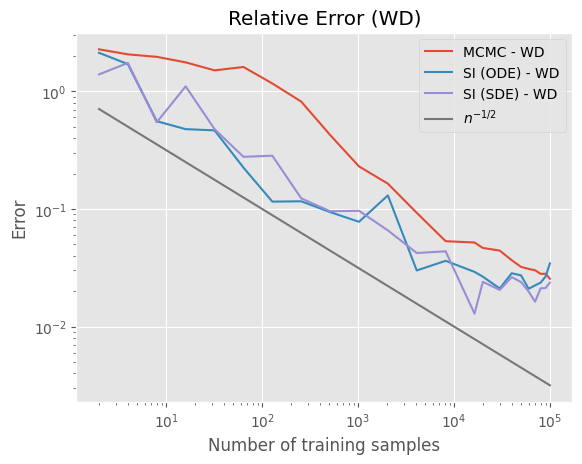

In [52]:
plt.plot(sample_no_list, rel_wd_array_mcmc, label="MCMC - WD")
plt.plot(sample_no_list, wd_array, label="SI (ODE) - WD")
plt.plot(sample_no_list, sde_wd_array, label="SI (SDE) - WD")
plt.plot(sample_no_list, 1 / np.sqrt(sample_no_list), label=r"$n^{-1/2}$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of training samples")
plt.ylabel("Error")
plt.title("Relative Error (WD)")
plt.legend()

In [50]:
sde_wd_array

array([1.39184728, 1.74186206, 0.54566005, 1.10170196, 0.47687866,
       0.27720555, 0.28345899, 0.12292191, 0.0955522 , 0.09640898,
       0.06567372, 0.04217688, 0.04358954, 0.01287091, 0.02399415,
       0.02046401, 0.02629726, 0.02389705, 0.01984754, 0.0162411 ,
       0.02113032, 0.02123459, 0.02363128])

In [51]:
log_n = np.log(sample_no_list)
log_err = np.log(sde_wd_array)

mask = np.array(sample_no_list) >= 1000
slope, intercept = np.polyfit(log_n[mask], log_err[mask], deg=1)

print("slope = ", slope)
print("intercept = ", intercept)

slope =  -0.3158058847454357
intercept =  -0.4369432065394203
